# 07: NODE PREDICTION

This notebook applies the trained XGBoost deployment model to predict Land Surface Temperature at all network nodes for heat-weighted routing.

## MODULE SETUP

In [1]:
# Mount Google Drive.
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os

# Set working directory to project folder.
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/hot_hem"
os.chdir(BASE_DIR)

print(f"Working directory: {BASE_DIR}")

Working directory: /content/drive/MyDrive/Colab Notebooks/hot_hem


## IMPORT SETUP

In [3]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## PATH CONFIGURATION

In [4]:
# Input paths.
NODES_FILE = Path("data/outputs/features/network_nodes_with_raster_features.csv")
MODEL_FILE = Path("models/xgboost_deployment_model.pkl")

# Output path.
OUT_DIR = Path("data/outputs/predictions")
OUT_FILE = OUT_DIR / "network_nodes_with_predictions.csv"

# Create output directory.
OUT_DIR.mkdir(parents = True, exist_ok = True)

print("PATH CONFIGURATION")
print(f"Network nodes: {NODES_FILE}")
print(f"Model file: {MODEL_FILE}")
print(f"Output file: {OUT_FILE}")

PATH CONFIGURATION
Network nodes: data/outputs/features/network_nodes_with_raster_features.csv
Model file: models/xgboost_deployment_model.pkl
Output file: data/outputs/predictions/network_nodes_with_predictions.csv


## LOAD MODEL

In [5]:
# Load trained deployment model.
with open(MODEL_FILE, "rb") as f:
    model_data = pickle.load(f)

model = model_data["model"]
features = model_data["features"]
target = model_data["target"]
cv_rmse = model_data["cv_rmse"]
cv_r2 = model_data["cv_r2"]

print("MODEL DETAILS")
print(f"Target variable: {target}")
print(f"Number of features: {len(features)}")
print(f"Cross-validation RMSE: {cv_rmse:.4f}")
print(f"Cross-validation R2: {cv_r2:.4f}")
print("")
print("Required features:")
for i, feat in enumerate(features, 1):
    print(f"{i:2d}. {feat}")

MODEL DETAILS
Target variable: lst_celsius
Number of features: 11
Cross-validation RMSE: 0.6888
Cross-validation R2: 0.7961

Required features:
 1. ndvi
 2. emissivity
 3. palsar_hh_db
 4. palsar_hv_db
 5. palsar_hv_hh_ratio
 6. palsar_glcm_contrast
 7. palsar_glcm_homogeneity
 8. palsar_glcm_energy
 9. elevation_m
10. sky_view_factor
11. landcover_class


## LOAD NETWORK NODES

In [6]:
# Load network nodes with features.
df_nodes = pd.read_csv(NODES_FILE)

print(f"Loaded {len(df_nodes)} network nodes.")
print(f"Columns: {list(df_nodes.columns)}")
df_nodes.head()

Loaded 28437 network nodes.
Columns: ['osmid', 'y', 'x', 'street_count', 'highway', 'ref', 'railway', 'geometry', 'lon', 'lat', 'lst_kelvin', 'lst_celsius', 'ndvi', 'emissivity', 'palsar_hh_db', 'palsar_hv_db', 'palsar_hv_hh_ratio', 'palsar_glcm_contrast', 'palsar_glcm_homogeneity', 'palsar_glcm_energy', 'elevation_m', 'sky_view_factor', 'landcover_class']


,osmid,y,x,street_count,highway,ref,railway,geometry,lon,lat,...,emissivity,palsar_hh_db,palsar_hv_db,palsar_hv_hh_ratio,palsar_glcm_contrast,palsar_glcm_homogeneity,palsar_glcm_energy,elevation_m,sky_view_factor,landcover_class
0,366367367,10.813901,106.732449,1,NaN,NaN,NaN,POINT (106.7324492 10.8139013),106.732449,10.813901,...,2.7385,-6.660599,-10.774033,1.617577,6199.80,0.031244,0.158114,10.0,0.999971,2.0
1,366368182,10.742144,106.670913,3,NaN,NaN,NaN,POINT (106.6709134 10.7421444),106.670913,10.742144,...,2.6601,2.644283,-11.333757,-4.286137,3650.35,0.008234,0.165831,9.0,0.998736,2.0
2,366368194,10.790241,106.709544,3,NaN,NaN,NaN,POINT (106.7095438 10.7902412),106.709544,10.790241,...,2.7238,5.584384,-0.062562,-0.011203,2781.00,0.007803,0.158114,7.0,0.993674,2.0
3,366368313,10.754628,106.684140,4,NaN,NaN,NaN,POINT (106.6841396 10.7546276),106.684140,10.754628,...,2.7826,3.691487,-10.945781,-2.965141,3170.60,0.107993,0.165831,12.0,0.999859,2.0
4,366368540,10.742907,106.672759,4,NaN,NaN,NaN,POINT (106.6727592 10.742907),106.672759,10.742907,...,2.6605,7.113308,-10.508171,-1.477255,4261.00,0.003137,0.158114,6.0,0.990122,2.0


## VERIFY FEATURES

In [7]:
# Check that all required features are available.
missing_features = [f for f in features if f not in df_nodes.columns]

if missing_features:
    print(f"WARNING: Missing features: {missing_features}")
else:
    print("All required features are available.")

# Check feature completeness.
print("")
print("FEATURE COMPLETENESS")
for feat in features:
    if feat in df_nodes.columns:
        valid = df_nodes[feat].notna().sum()
        pct = valid / len(df_nodes) * 100
        print(f"{feat:35s}: {valid:6d} ({pct:5.1f}%)")

All required features are available.

FEATURE COMPLETENESS
ndvi                               :  28437 (100.0%)
emissivity                         :  28437 (100.0%)
palsar_hh_db                       :  28437 (100.0%)
palsar_hv_db                       :  28437 (100.0%)
palsar_hv_hh_ratio                 :  28437 (100.0%)
palsar_glcm_contrast               :  28437 (100.0%)
palsar_glcm_homogeneity            :  28437 (100.0%)
palsar_glcm_energy                 :  28437 (100.0%)
elevation_m                        :  28437 (100.0%)
sky_view_factor                    :  28437 (100.0%)
landcover_class                    :  28437 (100.0%)


## PREPARE PREDICTION DATA

In [8]:
# Extract feature matrix.
X_pred = df_nodes[features].copy()

print(f"Prediction samples: {len(X_pred)}")
print(f"Features: {len(features)}")

# Check for missing values.
missing_count = X_pred.isna().any(axis = 1).sum()
print(f"Samples with missing values: {missing_count} ({missing_count/len(X_pred)*100:.1f}%)")

Prediction samples: 28437
Features: 11
Samples with missing values: 0 (0.0%)


## PREDICT LST

In [9]:
# Apply model to predict LST.
# XGBoost handles NaN values internally.
predictions = model.predict(X_pred)

# Store predictions.
df_nodes["predicted_lst_celsius"] = predictions

print("Predictions complete.")
print("")
print("Predicted LST statistics:")
print(df_nodes["predicted_lst_celsius"].describe())

Predictions complete.

Predicted LST statistics:
count    28437.000000
mean        40.836853
std          1.750437
min         35.506641
25%         39.764751
50%         40.708843
75%         41.527264
max         46.361698
Name: predicted_lst_celsius, dtype: float64


## CREATE HEAT CATEGORIES

In [10]:
# Create heat categories for analysis.
def categorize_heat(temp):
    """
    Categorize LST into heat risk levels.
    """
    if pd.isna(temp):
        return "Unknown"
    elif temp < 30:
        return "Cool"
    elif temp < 35:
        return "Warm"
    elif temp < 40:
        return "Hot"
    else:
        return "Very Hot"

df_nodes["heat_category"] = df_nodes["predicted_lst_celsius"].apply(categorize_heat)

print("HEAT CATEGORY DISTRIBUTION")
print(df_nodes["heat_category"].value_counts())

HEAT CATEGORY DISTRIBUTION
heat_category
Very Hot    19758
Hot          8679
Name: count, dtype: int64


## VISUALIZE PREDICTIONS

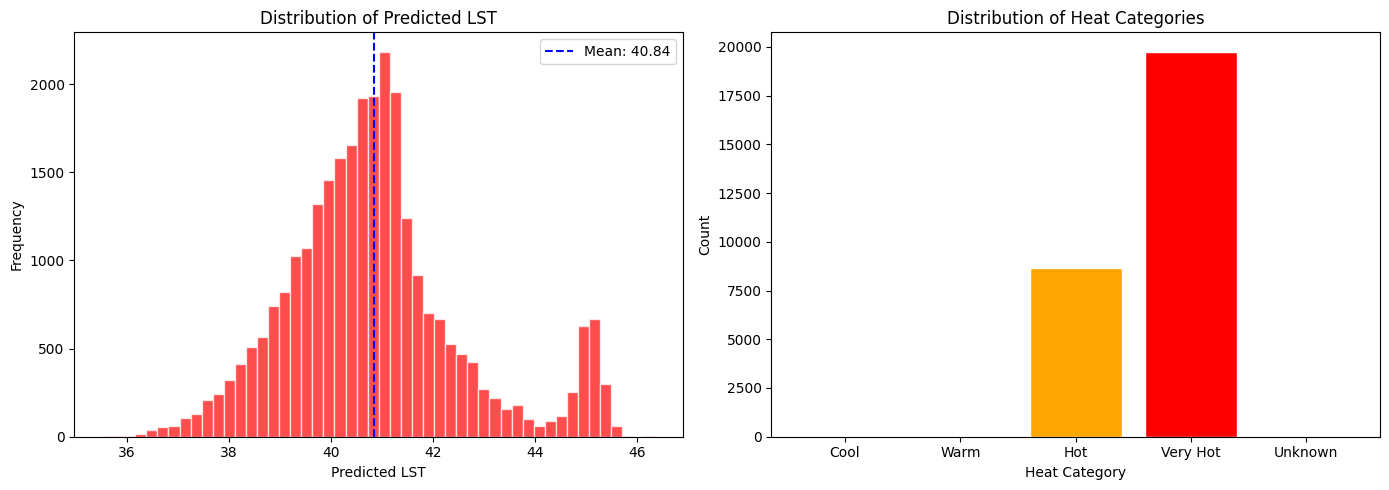

In [16]:
# Histogram of predicted LST.
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# LST distribution.
axes[0].hist(df_nodes["predicted_lst_celsius"].dropna(), bins = 50, color = "red", alpha = 0.7, edgecolor = "white")
axes[0].axvline(df_nodes["predicted_lst_celsius"].mean(), color = "blue", linestyle = "--", label = f"Mean: {df_nodes['predicted_lst_celsius'].mean():.2f}")
axes[0].set_xlabel("Predicted LST")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Predicted LST")
axes[0].legend()

# Heat category distribution.
category_order = ["Cool", "Warm", "Hot", "Very Hot", "Unknown"]
category_counts = df_nodes["heat_category"].value_counts().reindex(category_order, fill_value = 0)
colors = ["blue", "yellow", "orange", "red", "gray"]

axes[1].bar(category_counts.index, category_counts.values, color = colors, edgecolor = "white")
axes[1].set_xlabel("Heat Category")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Heat Categories")

plt.tight_layout()
plt.show()

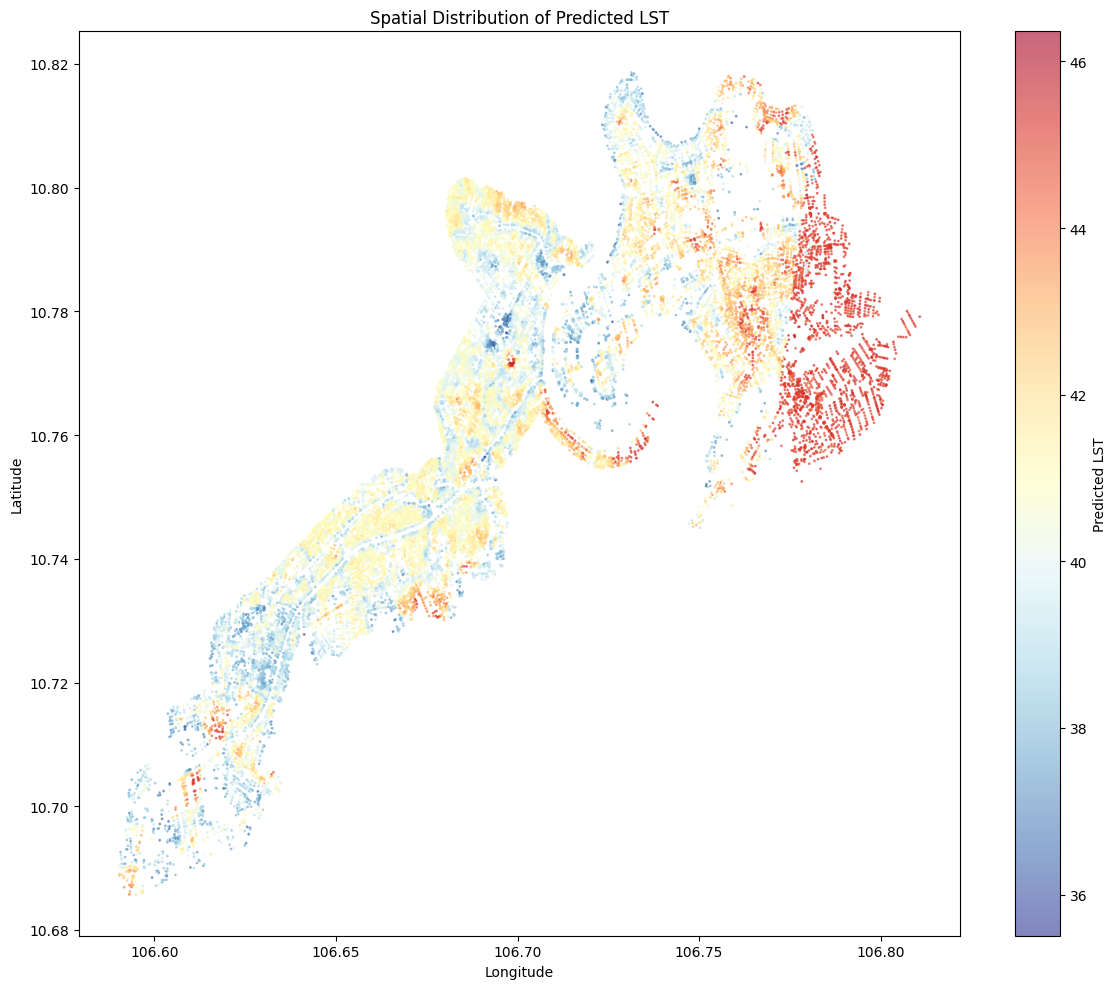

In [12]:
# Spatial distribution of predicted LST.
if "lon" in df_nodes.columns and "lat" in df_nodes.columns:
    fig, ax = plt.subplots(1, 1, figsize = (12, 10))

    scatter = ax.scatter(
        df_nodes["lon"],
        df_nodes["lat"],
        c = df_nodes["predicted_lst_celsius"],
        cmap = "RdYlBu_r",
        s = 1,
        alpha = 0.6
    )

    cbar = plt.colorbar(scatter, ax = ax, label = "Predicted LST")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Spatial Distribution of Predicted LST")

    plt.tight_layout()
    plt.show()
else:
    print("Latitude/longitude columns not available for spatial plot.")

## COMPARE WITH OBSERVED LST

COMPARISON WITH OBSERVED LST
Samples with both observed and predicted: 28332
RMSE: 1.3090
R2: 0.5952
MAE: 0.8461


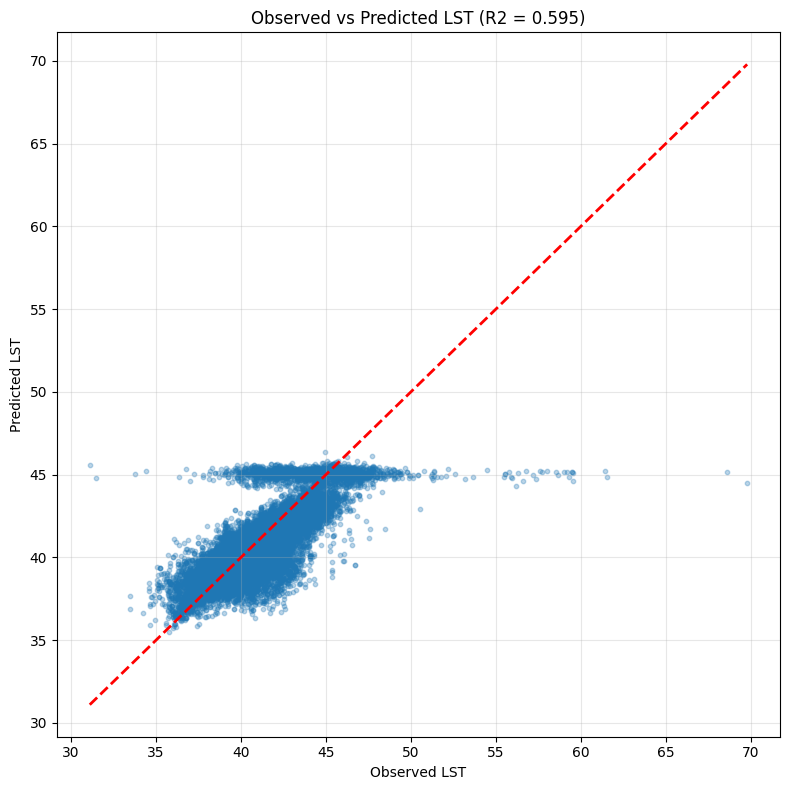

In [13]:
# Compare predicted vs observed LST where available.
if "lst_celsius" in df_nodes.columns:
    mask = df_nodes["lst_celsius"].notna() & df_nodes["predicted_lst_celsius"].notna()

    observed = df_nodes.loc[mask, "lst_celsius"]
    predicted = df_nodes.loc[mask, "predicted_lst_celsius"]

    if len(observed) > 0:
        from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

        rmse = np.sqrt(mean_squared_error(observed, predicted))
        r2 = r2_score(observed, predicted)
        mae = mean_absolute_error(observed, predicted)

        print("COMPARISON WITH OBSERVED LST")
        print(f"Samples with both observed and predicted: {len(observed)}")
        print(f"RMSE: {rmse:.4f}")
        print(f"R2: {r2:.4f}")
        print(f"MAE: {mae:.4f}")

        # Scatter plot.
        fig, ax = plt.subplots(1, 1, figsize = (8, 8))
        ax.scatter(observed, predicted, alpha = 0.3, s = 10)
        ax.plot([observed.min(), observed.max()], [observed.min(), observed.max()], "r--", lw = 2)
        ax.set_xlabel("Observed LST")
        ax.set_ylabel("Predicted LST")
        ax.set_title(f"Observed vs Predicted LST (R2 = {r2:.3f})")
        ax.grid(alpha = 0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("No samples with both observed and predicted LST.")
else:
    print("Observed LST column not available for comparison.")

## SAVE PREDICTIONS

In [14]:
# Save network nodes with predictions.
df_nodes.to_csv(OUT_FILE, index = False)

print("PREDICTIONS SAVED")
print(f"Output file: {OUT_FILE}")
print(f"Total nodes: {len(df_nodes)}")
print("")
print("Key prediction columns:")
print("predicted_lst_celsius: Predicted temperature for routing cost.")
print("heat_category: Categorical heat level for analysis.")

PREDICTIONS SAVED
Output file: data/outputs/predictions/network_nodes_with_predictions.csv
Total nodes: 28437

Key prediction columns:
predicted_lst_celsius: Predicted temperature for routing cost.
heat_category: Categorical heat level for analysis.


## SUMMARY

In [15]:
print("NODE PREDICTION SUMMARY")
print("")
print(f"Total network nodes: {len(df_nodes)}")
print(f"Nodes with predictions: {df_nodes['predicted_lst_celsius'].notna().sum()}")
print("")
print("Predicted LST range:")
print(f"Min: {df_nodes['predicted_lst_celsius'].min():.2f}")
print(f"Max: {df_nodes['predicted_lst_celsius'].max():.2f}")
print(f"Mean: {df_nodes['predicted_lst_celsius'].mean():.2f}")
print(f"Std: {df_nodes['predicted_lst_celsius'].std():.2f}")
print("")
print("Heat category breakdown:")
for cat in ["Cool", "Warm", "Hot", "Very Hot"]:
    count = (df_nodes["heat_category"] == cat).sum()
    pct = count / len(df_nodes) * 100
    print(f"{cat:10s}: {count:6d} ({pct:5.1f}%)")

NODE PREDICTION SUMMARY

Total network nodes: 28437
Nodes with predictions: 28437

Predicted LST range:
Min: 35.51
Max: 46.36
Mean: 40.84
Std: 1.75

Heat category breakdown:
Cool      :      0 (  0.0%)
Warm      :      0 (  0.0%)
Hot       :   8679 ( 30.5%)
Very Hot  :  19758 ( 69.5%)
